# Clustering and Dimensionality Reduction on Pima Indians Diabetes Dataset

## Aim
To apply clustering and dimensionality reduction techniques to the Pima Indians Diabetes Dataset to discover hidden patterns and visualize relationships among patients.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

df = pd.read_csv(url, names=columns)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age     

## Data Preprocessing

Zero values in Glucose, BloodPressure, SkinThickness, Insulin and BMI are treated as invalid/missing values and replaced with NaN.

In [4]:
invalid_columns = [
    "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"
]

df[invalid_columns] = df[invalid_columns].replace(0, np.nan)

features = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
]

X = df[features]
y = df["Outcome"]

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496


## Elbow Method

The Elbow Method is used to identify a suitable number of clusters by comparing the within-cluster sum of squares for different values of k.

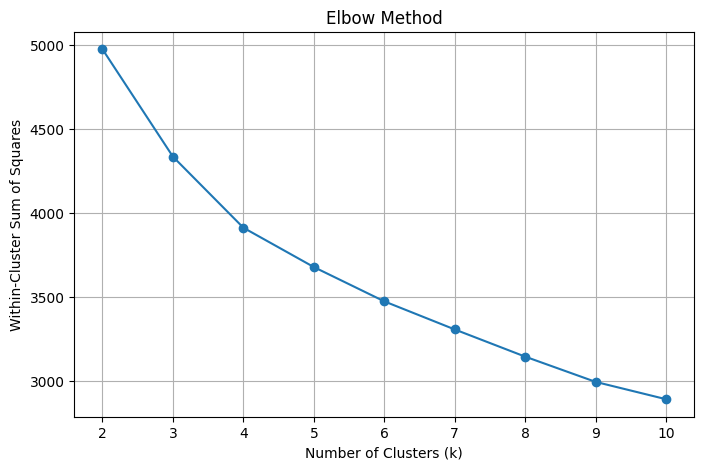

In [5]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares")
plt.title("Elbow Method")
plt.grid()
plt.show()

## Select Number of Clusters

For this experiment, k = 2 is selected because the dataset has two known Outcome categories and the elbow curve provides a simple two-group structure for comparison.

In [6]:
k = 2

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("Cluster Counts:")
print(df["Cluster"].value_counts().sort_index())

Cluster Counts:
Cluster
0    351
1    417
Name: count, dtype: int64


## Silhouette Score

The Silhouette Score measures how well observations fit within their assigned clusters. Higher values generally indicate better-defined clusters.

In [7]:
silhouette = silhouette_score(X_scaled, clusters)

print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.1963


## PCA Dimensionality Reduction

PCA is used to transform the standardized features into two principal components for visualization.

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = clusters
pca_df["Outcome"] = y.values

print("Explained Variance Ratio:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Total: {pca.explained_variance_ratio_.sum():.4f}")

Explained Variance Ratio:
PC1: 0.2854
PC2: 0.1869
Total: 0.4723


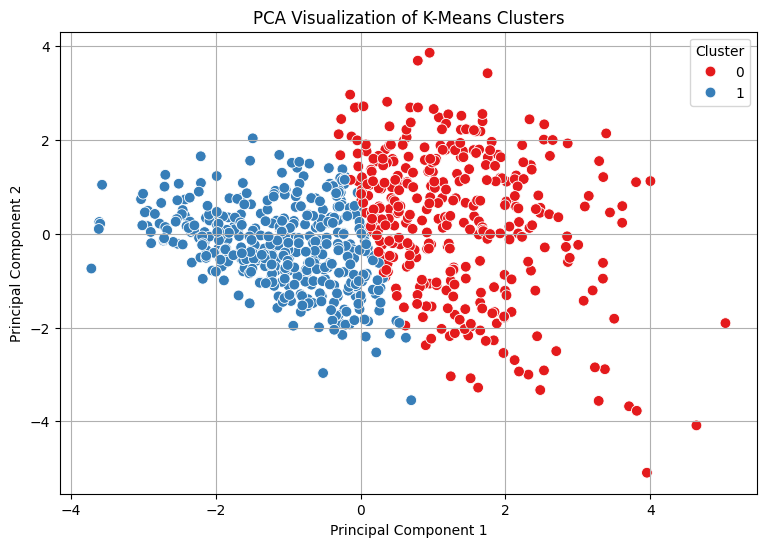

In [9]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=60
)
plt.title("PCA Visualization of K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

## PCA Feature Contributions

The PCA loadings show how strongly each original variable contributes to PC1 and PC2.

In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
)

print("PCA Loadings:")
print(loadings.round(4))

print("\nVariables contributing most to PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False))

print("\nVariables contributing most to PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False))

PCA Loadings:
                             PC1     PC2
Pregnancies               0.3014  0.5580
Glucose                   0.4240 -0.0820
BloodPressure             0.3772  0.1720
SkinThickness             0.3971 -0.3087
Insulin                   0.3071 -0.2358
BMI                       0.4018 -0.3985
DiabetesPedigreeFunction  0.1569 -0.2735
Age                       0.3860  0.5176

Variables contributing most to PC1:
Glucose                     0.423980
BMI                         0.401844
SkinThickness               0.397103
Age                         0.386013
BloodPressure               0.377177
Insulin                     0.307134
Pregnancies                 0.301434
DiabetesPedigreeFunction    0.156874
Name: PC1, dtype: float64

Variables contributing most to PC2:
Pregnancies                 0.557960
Age                         0.517560
BMI                         0.398489
SkinThickness               0.308746
DiabetesPedigreeFunction    0.273482
Insulin                     0.235780

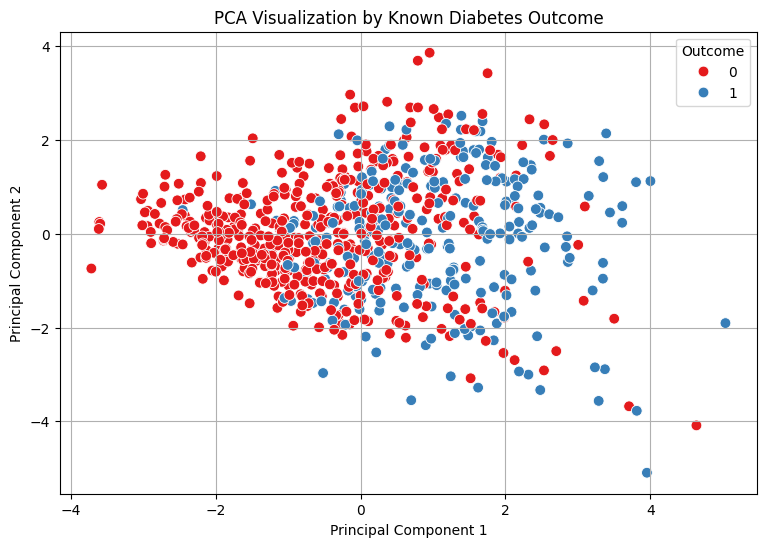

In [11]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Outcome",
    palette="Set1",
    s=60
)
plt.title("PCA Visualization by Known Diabetes Outcome")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

## Compare Clusters with Known Outcome

The Outcome variable was not used to create the clusters. It is used here only to compare the discovered groups with the known diabetes categories.

In [12]:
comparison = pd.crosstab(
    df["Cluster"],
    df["Outcome"],
    margins=True
)

print(comparison)

ari = adjusted_rand_score(y, clusters)
print(f"\nAdjusted Rand Index: {ari:.4f}")

Outcome    0    1  All
Cluster               
0        156  195  351
1        344   73  417
All      500  268  768

Adjusted Rand Index: 0.1614


In [13]:
print("Cluster-wise Outcome Distribution:")
print(pd.crosstab(df["Cluster"], df["Outcome"], normalize="index").round(3))

Cluster-wise Outcome Distribution:
Outcome      0      1
Cluster              
0        0.444  0.556
1        0.825  0.175
